Develop an RFM (Recency, Frequency, Monetary) and Cohort Analysis system to segment customers and analyze retention trends.  

## Time based cohort analysis used for checking 

--> signup and first purchases.


--> this typs based on the dataset the we are taking. 

In [1]:
#importing library
import pandas as pd
import numpy as np

#visualization library
import matplotlib.pyplot as plt
import seaborn as sns

#ml training and testing library
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

## LOADING THE DATASET IN pd

In [2]:
data = pd.read_csv("retail_customer.csv")
data

,InvoiceDate,InvoiceNo,StockCode,Description,Quantity,UnitPrice,CustomerID,Age,Gender,Income,Country
0,12/1/2010 8:26,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2.55,17850.0,77,female,26300.79466,United Kingdom
1,12/1/2010 8:26,536365,71053,WHITE METAL LANTERN,6,3.39,17850.0,77,female,26300.79466,United Kingdom
2,12/1/2010 8:26,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2.75,17850.0,77,female,26300.79466,United Kingdom
3,12/1/2010 8:26,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,3.39,17850.0,77,female,26300.79466,United Kingdom
4,12/1/2010 8:26,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,3.39,17850.0,77,female,26300.79466,United Kingdom
...,...,...,...,...,...,...,...,...,...,...,...
541904,12/9/2011 12:50,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,0.85,12680.0,26,male,31414.34048,France
541905,12/9/2011 12:50,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2.10,12680.0,26,male,31414.34048,France
541906,12/9/2011 12:50,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,4.15,12680.0,26,male,31414.34048,France
541907,12/9/2011 12:50,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,4.15,12680.0,26,male,31414.34048,France


In [3]:
data.head(5)

,InvoiceDate,InvoiceNo,StockCode,Description,Quantity,UnitPrice,CustomerID,Age,Gender,Income,Country
0,12/1/2010 8:26,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2.55,17850.0,77,female,26300.79466,United Kingdom
1,12/1/2010 8:26,536365,71053,WHITE METAL LANTERN,6,3.39,17850.0,77,female,26300.79466,United Kingdom
2,12/1/2010 8:26,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2.75,17850.0,77,female,26300.79466,United Kingdom
3,12/1/2010 8:26,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,3.39,17850.0,77,female,26300.79466,United Kingdom
4,12/1/2010 8:26,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,3.39,17850.0,77,female,26300.79466,United Kingdom


In [4]:
data.tail(5)

,InvoiceDate,InvoiceNo,StockCode,Description,Quantity,UnitPrice,CustomerID,Age,Gender,Income,Country
541904,12/9/2011 12:50,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,0.85,12680.0,26,male,31414.34048,France
541905,12/9/2011 12:50,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2.10,12680.0,26,male,31414.34048,France
541906,12/9/2011 12:50,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,4.15,12680.0,26,male,31414.34048,France
541907,12/9/2011 12:50,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,4.15,12680.0,26,male,31414.34048,France
541908,12/9/2011 12:50,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,4.95,12680.0,26,male,31414.34048,France


In [5]:
data['InvoiceDate'] = pd.to_datetime(data['InvoiceDate'])

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 11 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceDate  541909 non-null  datetime64[ns]
 1   InvoiceNo    541909 non-null  object        
 2   StockCode    541909 non-null  object        
 3   Description  540455 non-null  object        
 4   Quantity     541909 non-null  int64         
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Age          541909 non-null  int64         
 8   Gender       541909 non-null  object        
 9   Income       541909 non-null  float64       
 10  Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(3), int64(2), object(5)
memory usage: 45.5+ MB


## before removing the duplicates

In [7]:
data.describe()

,InvoiceDate,Quantity,UnitPrice,CustomerID,Age,Income
count,541909,541909.000000,541909.000000,406829.000000,541909.000000,541909.000000
mean,2011-07-04 13:34:57.156386048,9.552250,4.611114,15287.690570,34.885486,33127.125613
min,2010-12-01 08:26:00,-80995.000000,-11062.060000,12346.000000,15.000000,18662.725640
25%,2011-03-28 11:34:00,1.000000,1.250000,13953.000000,25.000000,32130.475290
50%,2011-07-19 17:17:00,3.000000,2.080000,15152.000000,31.000000,32443.374420
75%,2011-10-19 11:27:00,10.000000,4.130000,16791.000000,43.000000,33795.299830
max,2011-12-09 12:50:00,80995.000000,38970.000000,18287.000000,100.000000,45925.206370
std,NaN,218.081158,96.759853,1713.600303,12.996630,5619.977488


In [8]:
data.nunique()

InvoiceDate    23260
InvoiceNo      25900
StockCode       4070
Description     4223
Quantity         722
UnitPrice       1630
CustomerID      4372
Age               80
Gender             2
Income          4373
Country           38
dtype: int64

In [9]:
data.isnull().sum()

InvoiceDate         0
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
UnitPrice           0
CustomerID     135080
Age                 0
Gender              0
Income              0
Country             0
dtype: int64

In [10]:
data = data.dropna(subset=['CustomerID'])

In [11]:
data.isnull().sum().sum()

np.int64(0)

In [12]:
data= data.drop_duplicates()

In [13]:
data.duplicated().sum()

np.int64(0)

In [14]:
data.shape

(401604, 11)

In [15]:
data.columns

Index(['InvoiceDate', 'InvoiceNo', 'StockCode', 'Description', 'Quantity',
       'UnitPrice', 'CustomerID', 'Age', 'Gender', 'Income', 'Country'],
      dtype='object')

In [16]:
data.describe()

,InvoiceDate,Quantity,UnitPrice,CustomerID,Age,Income
count,401604,401604.000000,401604.000000,401604.000000,401604.000000,401604.000000
mean,2011-07-10 12:08:23.848567552,12.183273,3.474064,15281.160818,38.169640,33461.855398
min,2010-12-01 08:26:00,-80995.000000,0.000000,12346.000000,15.000000,18662.725640
25%,2011-04-06 15:02:00,2.000000,1.250000,13939.000000,28.000000,32029.371630
50%,2011-07-29 15:40:00,5.000000,1.950000,15145.000000,36.000000,32989.061560
75%,2011-10-20 11:58:30,12.000000,3.750000,16784.000000,45.000000,35186.809490
max,2011-12-09 12:50:00,80995.000000,38970.000000,18287.000000,100.000000,45925.206370
std,NaN,250.283037,69.764035,1714.006089,13.477881,6452.510147


## From data.describe(), I observed that the minimum value of Quantity is negative and the minimum value of UnitPrice is 0. These values represent invalid or non-purchase transactions, so I removed them using the following code

In [17]:
data = data[(data['Quantity']>0) & (data['UnitPrice']>0)]
data.describe()

,InvoiceDate,Quantity,UnitPrice,CustomerID,Age,Income
count,392692,392692.000000,392692.000000,392692.000000,392692.000000,392692.000000
mean,2011-07-10 19:13:07.771892480,13.119702,3.125914,15287.843865,38.166576,33463.612976
min,2010-12-01 08:26:00,1.000000,0.001000,12346.000000,15.000000,18662.725640
25%,2011-04-07 11:12:00,2.000000,1.250000,13955.000000,28.000000,32029.371630
50%,2011-07-31 12:02:00,6.000000,1.950000,15150.000000,36.000000,32989.061560
75%,2011-10-20 12:53:00,12.000000,3.750000,16791.000000,45.000000,35186.809490
max,2011-12-09 12:50:00,80995.000000,8142.750000,18287.000000,100.000000,45925.206370
std,NaN,180.492832,22.241836,1713.539549,13.479420,6455.340978


## DATA ANALYSIS

1. invoice period : A str rep of the year and month of single trancation
2. cohort group : A str rep of year and month of a customer's first purchase.
3. cohort period :A int rep a customer'stage in its 'lifetime'.no of months passed since the first purchase.

## CREATION OF invoice month

In [18]:
import datetime as dt

In [19]:
#Extracts the year and month from InvoiceDate.
#Sets the date to the first day of that month.
def get_month(x):
    return dt.datetime(x.year,x.month,1) 
    
    #Groups transactions based on each customer.
    grouping = data.groupby['InvoiceDate'].apply(get_month)
    
    #Finds the first purchase month of each customer.
    data['cohortmonth'].grouping.transform("min")
   

In [20]:
data['InvoiceDate'] = pd.to_datetime(data['InvoiceDate'])

In [21]:
#addition of invoicemonth to the dataset
data['InvoiceMonth'] = data['InvoiceDate'].apply(get_month)

In [22]:
data['CohortMonth'] = data.groupby('CustomerID')['InvoiceMonth'].transform('min')

In [23]:
data.tail(5)

,InvoiceDate,InvoiceNo,StockCode,Description,Quantity,UnitPrice,CustomerID,Age,Gender,Income,Country,InvoiceMonth,CohortMonth
541904,2011-12-09 12:50:00,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,0.85,12680.0,26,male,31414.34048,France,2011-12-01,2011-08-01
541905,2011-12-09 12:50:00,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2.10,12680.0,26,male,31414.34048,France,2011-12-01,2011-08-01
541906,2011-12-09 12:50:00,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,4.15,12680.0,26,male,31414.34048,France,2011-12-01,2011-08-01
541907,2011-12-09 12:50:00,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,4.15,12680.0,26,male,31414.34048,France,2011-12-01,2011-08-01
541908,2011-12-09 12:50:00,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,4.95,12680.0,26,male,31414.34048,France,2011-12-01,2011-08-01


## SEPERATION OF MONTH,DAY AND YEAR 

In [24]:
def get_month_int(data,column):
    year = data[column].dt.year
    month = data[column].dt.month
   
    return month, year

invoice_month,invoice_year = get_month_int(data,'InvoiceMonth')
cohort_month,cohort_year = get_month_int(data,'CohortMonth')

year_diff = invoice_year - cohort_year
month_diff = invoice_month - cohort_month

data['cohortIndex'] = year_diff * 12 + month_diff + 1
   
   
    

In [25]:
grouping = data.groupby(['CohortMonth','cohortIndex'])
cohort_data = grouping['CustomerID'].apply(pd.Series.nunique)

cohort_data = cohort_data.reset_index()
cohort_counts = cohort_data.pivot(index='CohortMonth', columns='cohortIndex', values='CustomerID')

In [26]:
cohort_counts

cohortIndex,1,2,3,4,5,6,7,8,9,10,11,12,13
CohortMonth,,,,,,,,,,,,,
2010-12-01,885.0,324.0,286.0,340.0,321.0,352.0,321.0,309.0,313.0,350.0,331.0,445.0,235.0
2011-01-01,417.0,92.0,111.0,96.0,134.0,120.0,103.0,101.0,125.0,136.0,152.0,49.0,NaN
2011-02-01,380.0,71.0,71.0,108.0,103.0,94.0,96.0,106.0,94.0,116.0,26.0,NaN,NaN
2011-03-01,452.0,68.0,114.0,90.0,101.0,76.0,121.0,104.0,126.0,39.0,NaN,NaN,NaN
2011-04-01,300.0,64.0,61.0,63.0,59.0,68.0,65.0,78.0,22.0,NaN,NaN,NaN,NaN
2011-05-01,284.0,54.0,49.0,49.0,59.0,66.0,75.0,27.0,NaN,NaN,NaN,NaN,NaN
2011-06-01,242.0,42.0,38.0,64.0,56.0,81.0,23.0,NaN,NaN,NaN,NaN,NaN,NaN
2011-07-01,188.0,34.0,39.0,42.0,51.0,21.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-08-01,169.0,35.0,42.0,41.0,21.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [27]:
#number of customers who joined in their first month (Month 0).
cohort_size = cohort_counts.iloc[:,0] 

#Divides each month's customer count by the original cohort size.
retention = cohort_counts.divide(cohort_size, axis =0)

#roundoff the value upto 3 decimal
retention.round(3)*100

cohortIndex,1,2,3,4,5,6,7,8,9,10,11,12,13
CohortMonth,,,,,,,,,,,,,
2010-12-01,100.0,36.6,32.3,38.4,36.3,39.8,36.3,34.9,35.4,39.5,37.4,50.3,26.6
2011-01-01,100.0,22.1,26.6,23.0,32.1,28.8,24.7,24.2,30.0,32.6,36.5,11.8,NaN
2011-02-01,100.0,18.7,18.7,28.4,27.1,24.7,25.3,27.9,24.7,30.5,6.8,NaN,NaN
2011-03-01,100.0,15.0,25.2,19.9,22.3,16.8,26.8,23.0,27.9,8.6,NaN,NaN,NaN
2011-04-01,100.0,21.3,20.3,21.0,19.7,22.7,21.7,26.0,7.3,NaN,NaN,NaN,NaN
2011-05-01,100.0,19.0,17.3,17.3,20.8,23.2,26.4,9.5,NaN,NaN,NaN,NaN,NaN
2011-06-01,100.0,17.4,15.7,26.4,23.1,33.5,9.5,NaN,NaN,NaN,NaN,NaN,NaN
2011-07-01,100.0,18.1,20.7,22.3,27.1,11.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-08-01,100.0,20.7,24.9,24.3,12.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## DISPLAY VISULIZATION start 8/7/26

<Axes: xlabel='cohortIndex', ylabel='CohortMonth'>

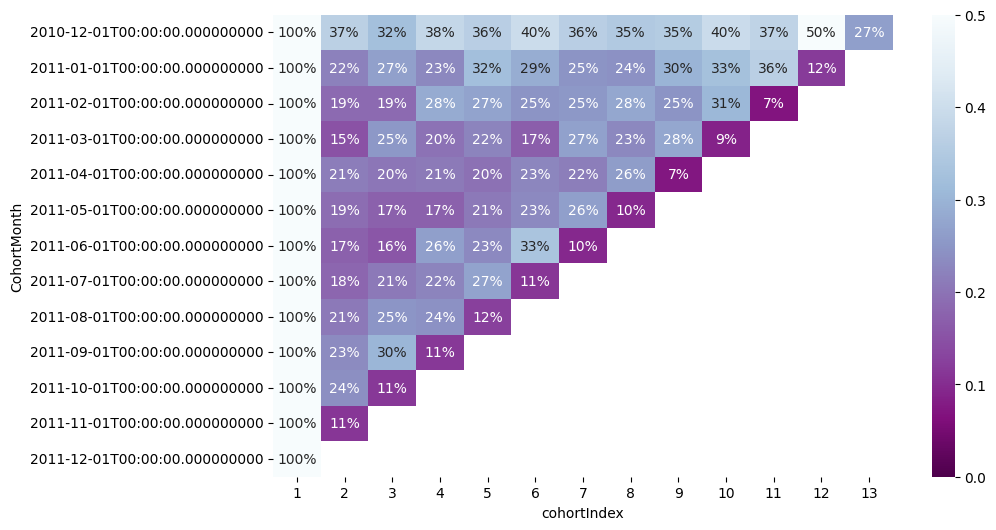

In [28]:
plt.figure(figsize = (10,6))

#annot=True → Displays the retention value inside each cell.
#.0% should it in %format of the retention table value
sns.heatmap(data = retention,annot = True, fmt = '.0%',vmin = 0.0,vmax=0.5,cmap = 'BuPu_r')

<Axes: xlabel='cohortIndex'>

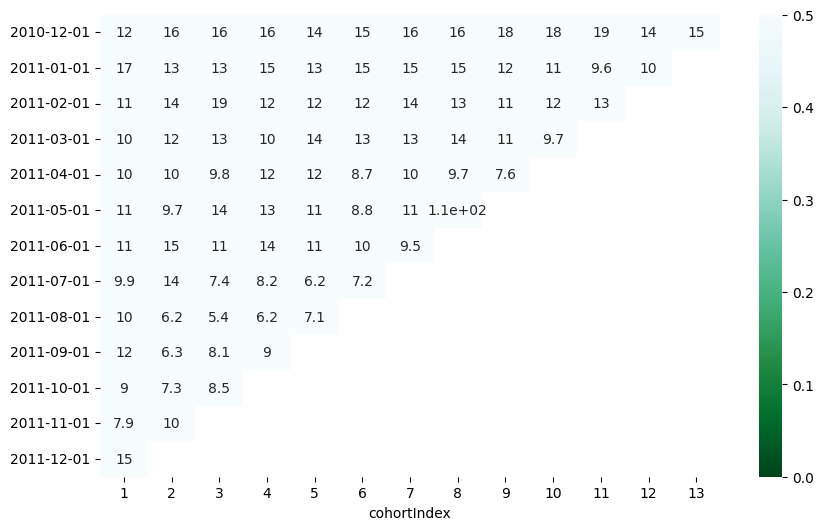

In [29]:
grouping = data.groupby(['CohortMonth', 'cohortIndex'])
cohort_data = grouping['Quantity'].mean()
cohort_data = cohort_data.reset_index()

average_quantity = cohort_data.pivot(index= 'CohortMonth',columns = 'cohortIndex',values = 'Quantity')
average_quantity.round(1)
average_quantity.index = average_quantity.index.date

plt.figure(figsize = (10,6))
sns.heatmap(data = average_quantity,annot = True, vmin = 0.0,vmax=0.5,cmap = "BuGn_r")

## RFM CALCULATION

RFM - Recency, Frequency and Monetary

R - when the last purchase has been done.

F - how frequenctly the customer comes to the website and makes a order.

M - how much of amount is spend in that given period of time.

In [30]:
#New as total sum = up*quantity
data['TotalSum'] = data['UnitPrice']*data['Quantity']

print('min Invoice Date:',data.InvoiceDate.dt.date.min(),
      'max Invoice Date:',data.InvoiceDate.dt.date.max())

data.head(5)

#dt.date → Extracts only the date (removes the time).
#min() → Finds the earliest invoice date.
#max() → Finds the latest invoice date.

min Invoice Date: 2010-12-01 max Invoice Date: 2011-12-09


,InvoiceDate,InvoiceNo,StockCode,Description,Quantity,UnitPrice,CustomerID,Age,Gender,Income,Country,InvoiceMonth,CohortMonth,cohortIndex,TotalSum
0,2010-12-01 08:26:00,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2.55,17850.0,77,female,26300.79466,United Kingdom,2010-12-01,2010-12-01,1,15.30
1,2010-12-01 08:26:00,536365,71053,WHITE METAL LANTERN,6,3.39,17850.0,77,female,26300.79466,United Kingdom,2010-12-01,2010-12-01,1,20.34
2,2010-12-01 08:26:00,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2.75,17850.0,77,female,26300.79466,United Kingdom,2010-12-01,2010-12-01,1,22.00
3,2010-12-01 08:26:00,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,3.39,17850.0,77,female,26300.79466,United Kingdom,2010-12-01,2010-12-01,1,20.34
4,2010-12-01 08:26:00,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,3.39,17850.0,77,female,26300.79466,United Kingdom,2010-12-01,2010-12-01,1,20.34


In [31]:
#every customer has a recency of at least 1 day with  the time stamp
snapshot_date = data['InvoiceDate'].max()+dt.timedelta(days = 1) #current date +1
snapshot_date

Timestamp('2011-12-10 12:50:00')

In [32]:
#calculate RFM METRICS
rfm = data.groupby(['CustomerID']).agg({'InvoiceDate': lambda x:(snapshot_date - x.max()).days,
                                        'InvoiceNo':'count','TotalSum': 'sum'})

#rename
rfm.rename(columns={'InvoiceDate':'Recency',#VISITING DATA
                   'InvoiceNo': 'Frequency',#ACTIVE DATA
                   'TotalSum':'MonetaryValue'},inplace= True)#PURCHASE DATA
rfm.head()

,Recency,Frequency,MonetaryValue
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,182,4310.00
12348.0,75,31,1797.24
12349.0,19,73,1757.55
12350.0,310,17,334.40


## x.max() → Finds the customer's most recent purchase date.
snapshot_date - x.max() → Calculates the number of days since their last purchase.
.days → Returns the difference in days.

In [33]:
#Building RFM segments
r_labels = range(4,0,-1)
f_labels = range(1,5)
m_labels = range(1,5)
r_quartiles = pd.qcut(rfm['Recency'], q=4, labels = r_labels)
f_quartiles = pd.qcut(rfm['Frequency'], q=4, labels = f_labels)
m_quartiles = pd.qcut(rfm['MonetaryValue'], q=4, labels = m_labels)
rfm = rfm.assign(R=r_quartiles, F=f_quartiles, M=m_quartiles)

# Build RFM Segment and RFM Score
def add_rfm(x): return str(x['R']) + str(x['F']) + str(x['M'])
rfm['RFM_Segment'] = rfm.apply(add_rfm, axis=1)
rfm['RFM_Score'] = rfm[['R','F','M']].sum(axis=1)

rfm.head()

,Recency,Frequency,MonetaryValue,R,F,M,RFM_Segment,RFM_Score
CustomerID,,,,,,,,
12346.0,326,1,77183.60,1,1,4,1.01.04.0,6
12347.0,2,182,4310.00,4,4,4,4.04.04.0,12
12348.0,75,31,1797.24,2,2,4,2.02.04.0,8
12349.0,19,73,1757.55,3,3,4,3.03.04.0,10
12350.0,310,17,334.40,1,1,2,1.01.02.0,4


In [34]:
rfm.groupby('RFM_Score').agg({'Recency':'mean',
                              'Frequency':'mean',
                              'MonetaryValue':['mean','count']}).round(1) #decimal value

Recency Frequency MonetaryValue      
             mean      mean          mean count
RFM_Score                                      
3           260.7       8.2         157.4   381
4           177.2      13.6         240.0   388
5           152.9      21.2         366.6   518
6            95.9      27.9         820.8   457
7            79.6      38.0         758.1   463
8            64.1      56.0         987.3   454
9            45.9      78.7        1795.1   414
10           32.4     110.5        2056.4   426
11           21.3     186.9        4062.0   387
12            7.2     367.8        9285.9   450

In [35]:
# ---- RFM Segment Calculation ----
def segments(data):
    if data['RFM_Score'] > 9:
        return 'Gold'
    elif (data['RFM_Score'] > 5) and (data['RFM_Score'] <= 9):
        return 'Silver'
    else:
        return 'Bronze'

rfm['General_Segment'] = rfm.apply(segments, axis=1)

In [36]:
rfm_rfm = rfm[['Recency','Frequency','MonetaryValue']]
print(rfm_rfm.describe())

           Recency    Frequency  MonetaryValue
count  4338.000000  4338.000000    4338.000000
mean     92.536422    90.523744    2048.688081
std     100.014169   225.506968    8985.230220
min       1.000000     1.000000       3.750000
25%      18.000000    17.000000     306.482500
50%      51.000000    41.000000     668.570000
75%     142.000000    98.000000    1660.597500
max     374.000000  7676.000000  280206.020000


In [37]:
print(data.columns)

Index(['InvoiceDate', 'InvoiceNo', 'StockCode', 'Description', 'Quantity',
       'UnitPrice', 'CustomerID', 'Age', 'Gender', 'Income', 'Country',
       'InvoiceMonth', 'CohortMonth', 'cohortIndex', 'TotalSum'],
      dtype='object')


In [38]:
print(rfm.columns)

Index(['Recency', 'Frequency', 'MonetaryValue', 'R', 'F', 'M', 'RFM_Segment',
       'RFM_Score', 'General_Segment'],
      dtype='object')


In [39]:
#applying logrithm
rfm_log = rfm[['Recency', 'Frequency', 'MonetaryValue']].apply(np.log, axis=1).round(3)
rfm_log

,Recency,Frequency,MonetaryValue
CustomerID,,,
12346.0,5.787,0.000,11.254
12347.0,0.693,5.204,8.369
12348.0,4.317,3.434,7.494
12349.0,2.944,4.290,7.472
12350.0,5.737,2.833,5.812
...,...,...,...
18280.0,5.628,2.303,5.196
18281.0,5.198,1.946,4.392
18282.0,2.079,2.485,5.182


## DISPLAYING THE SCALING VARIABLE

In [40]:
# ---- Step 1: Log Transformation ----
df_rfm = rfm[['Recency', 'Frequency', 'MonetaryValue']]
df_log = np.log(df_rfm).round(3)

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_9440\4281618687.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  plt.subplot(3, 1, 1); sns.distplot(df_log.Recency, label='Recency')
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_9440\4281618687.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  plt.subplot(3, 1, 2); sns.dist

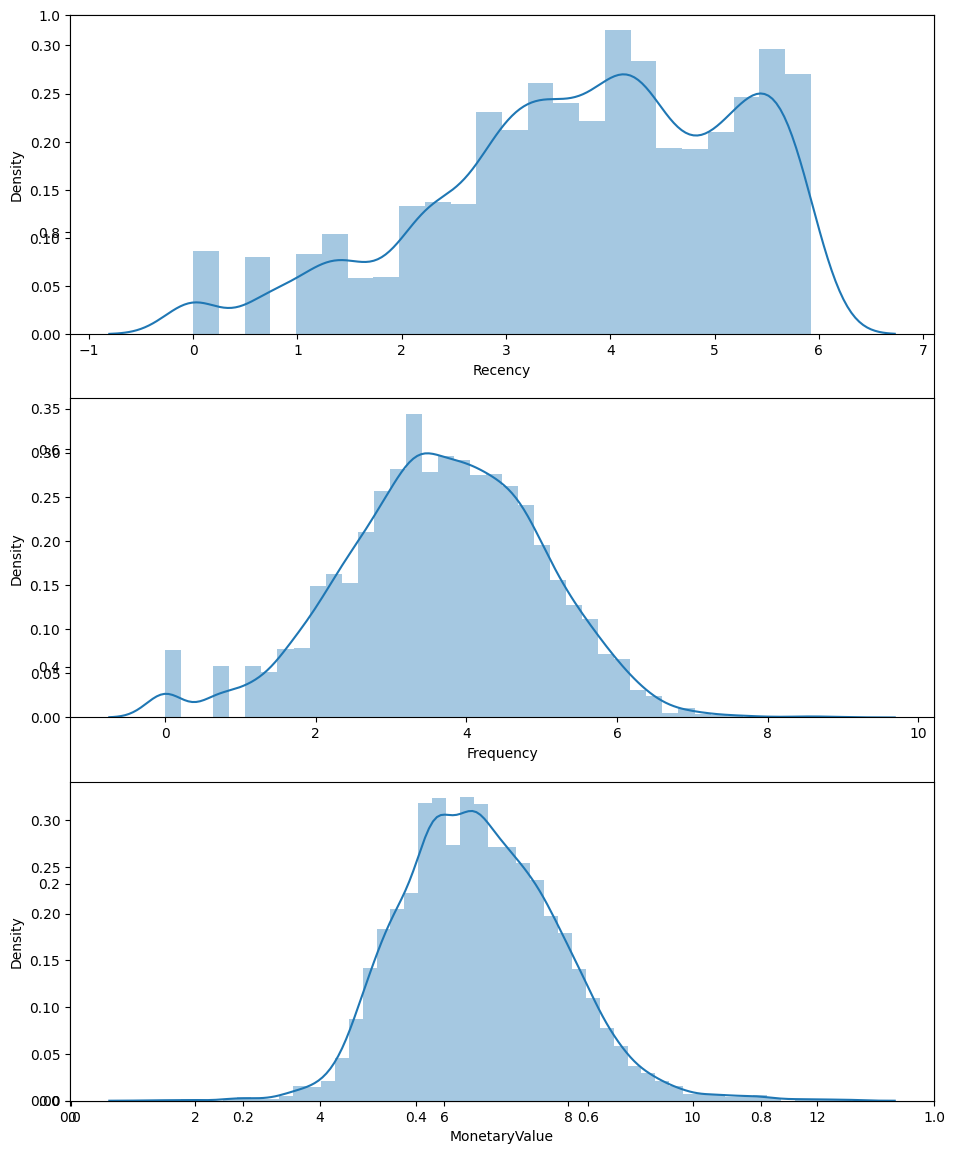

In [41]:
f, ax = plt.subplots(figsize=(10, 12))
plt.subplot(3, 1, 1); sns.distplot(df_log.Recency, label='Recency')
plt.subplot(3, 1, 2); sns.distplot(df_log.Frequency, label='Frequency')
plt.subplot(3, 1, 3); sns.distplot(df_log.MonetaryValue, label='Monetary Value')
plt.style.use('fivethirtyeight')
plt.tight_layout()
plt.show()

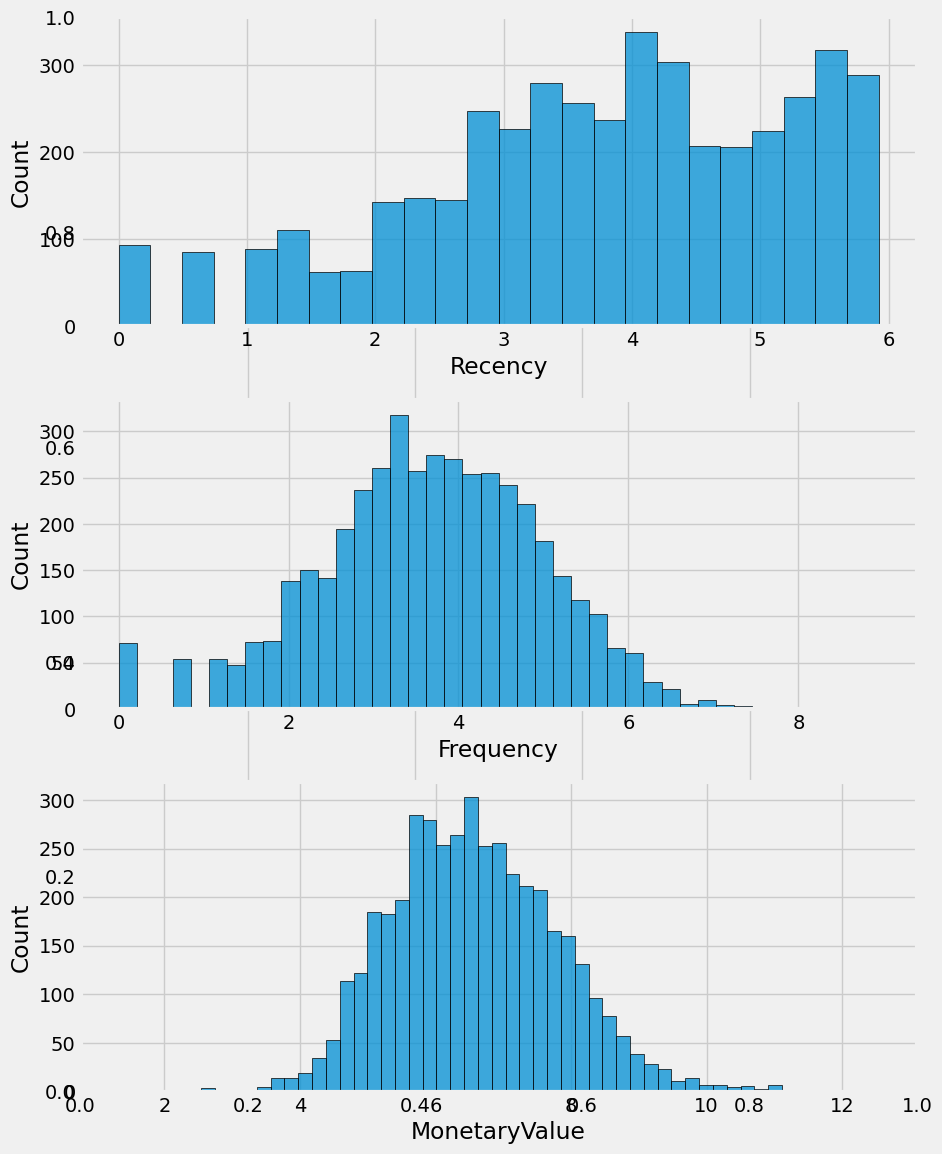

In [42]:
f, ax = plt.subplots(figsize=(10, 12))
plt.subplot(3, 1, 1); sns.histplot(df_log.Recency, label='Recency',edgecolor = 'black')
plt.subplot(3, 1, 2); sns.histplot(df_log.Frequency, label='Frequency',edgecolor = 'black')
plt.subplot(3, 1, 3); sns.histplot(df_log.MonetaryValue, label='Monetary Value',edgecolor = 'black')
plt.style.use('fivethirtyeight')
plt.tight_layout()
plt.show()

problem:unsymmetric distribution of variable(data skewed)

solution: taking log transformation will manage skewed.

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_9440\881161628.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  plt.subplot(3, 1, 1); sns.distplot(df_log.Recency, label='Recency')
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_9440\881161628.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  plt.subplot(3, 1, 2); sns.distpl

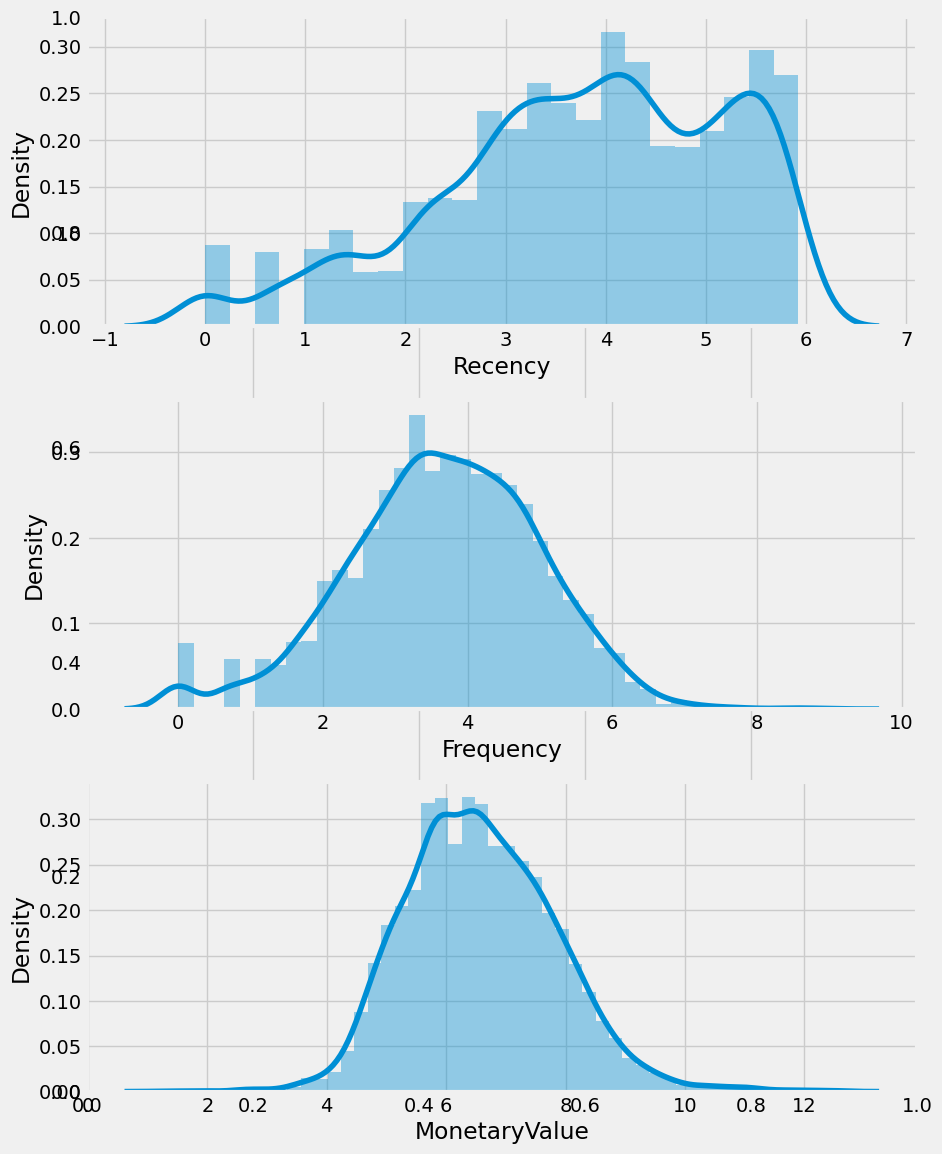

In [43]:
df_log = rfm[['Recency', 'Frequency', 'MonetaryValue']].apply(np.log, axis=1).round(3)

f, ax = plt.subplots(figsize=(10, 12))
plt.subplot(3, 1, 1); sns.distplot(df_log.Recency, label='Recency')
plt.subplot(3, 1, 2); sns.distplot(df_log.Frequency, label='Frequency')
plt.subplot(3, 1, 3); sns.distplot(df_log.MonetaryValue, label='Monetary Value')
plt.style.use('fivethirtyeight')
plt.tight_layout()
plt.show()

## KMEAN clustering

## steps
1. datapre-processing
2. choose a number of cluster
3. running k-means clusitering
4. analyse the average 

In [44]:
# ---- Step 2: Standardize ----
scaler = StandardScaler()
scaler.fit(df_log)
df_normalized = scaler.transform(df_log)

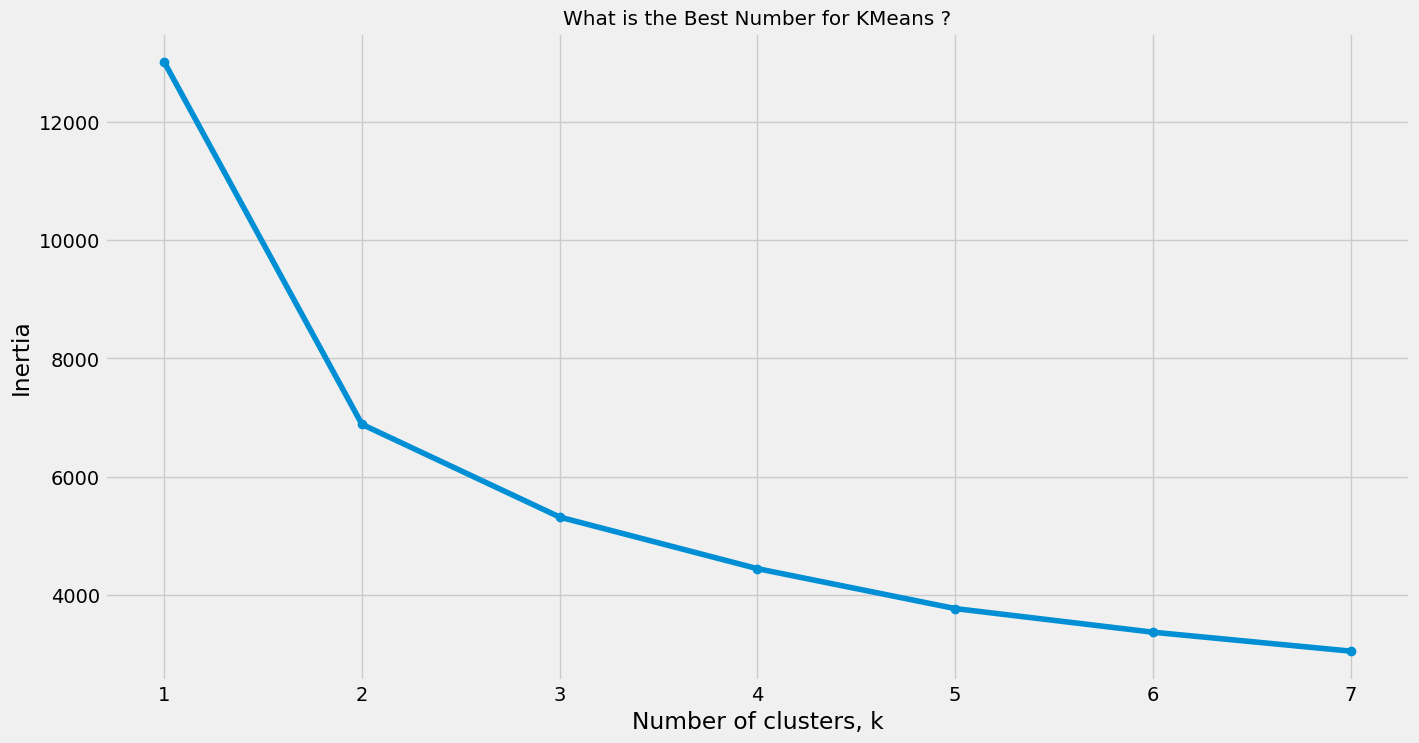

In [45]:
# ---- Step 3: Elbow Method ----
ks = range(1, 8)
inertias = []
for k in ks:
    kc = KMeans(n_clusters=k, random_state=1)
    kc.fit(df_normalized)
    inertias.append(kc.inertia_)

f, ax = plt.subplots(figsize=(15, 8))
plt.plot(ks, inertias, '-o')
plt.xlabel('Number of clusters, k')
plt.ylabel('Inertia')
plt.xticks(ks)
plt.style.use('ggplot')
plt.title('What is the Best Number for KMeans ?')
plt.show()

In [46]:
# ---- Step 4: Final Clustering (k=3) ----
kc = KMeans(n_clusters=3, random_state=1)
kc.fit(df_normalized)
cluster_labels = kc.labels_

df_rfm_k3 = df_rfm.assign(K_Cluster=cluster_labels)
print(df_rfm_k3.groupby('K_Cluster').agg({
    'Recency': 'mean', 'Frequency': 'mean',
    'MonetaryValue': ['mean', 'count']
}).round(0))

          Recency Frequency MonetaryValue      
             mean      mean          mean count
K_Cluster                                      
0            69.0      66.0        1183.0  1850
1            13.0     262.0        6610.0   945
2           170.0      15.0         294.0  1543


In [47]:
rfm_normalized = pd.DataFrame(
    df_normalized,
    index=rfm.index,
    columns=['Recency', 'Frequency', 'MonetaryValue']
)

In [48]:
rfm_normalized = pd.DataFrame(
    rfm_normalized,
    index=rfm.index,
    columns=rfm.columns
)

rfm_normalized['K_cluster'] = kc.labels_
rfm_normalized['General_Segment'] = rfm['General_Segment']

rfm_normalized.reset_index(inplace=True)

rfm_melt = pd.melt(
    rfm_normalized,
    id_vars=['CustomerID', 'General_Segment', 'K_cluster'],
    value_vars=['Recency', 'Frequency', 'MonetaryValue'],
    var_name='Metric',
    value_name='Value'
)

rfm_melt.head()

,CustomerID,General_Segment,K_cluster,Metric,Value
0,12346.0,Silver,0,Recency,1.409982
1,12347.0,Gold,1,Recency,-2.146578
2,12348.0,Silver,0,Recency,0.383648
3,12349.0,Gold,0,Recency,-0.574961
4,12350.0,Bronze,2,Recency,1.375072


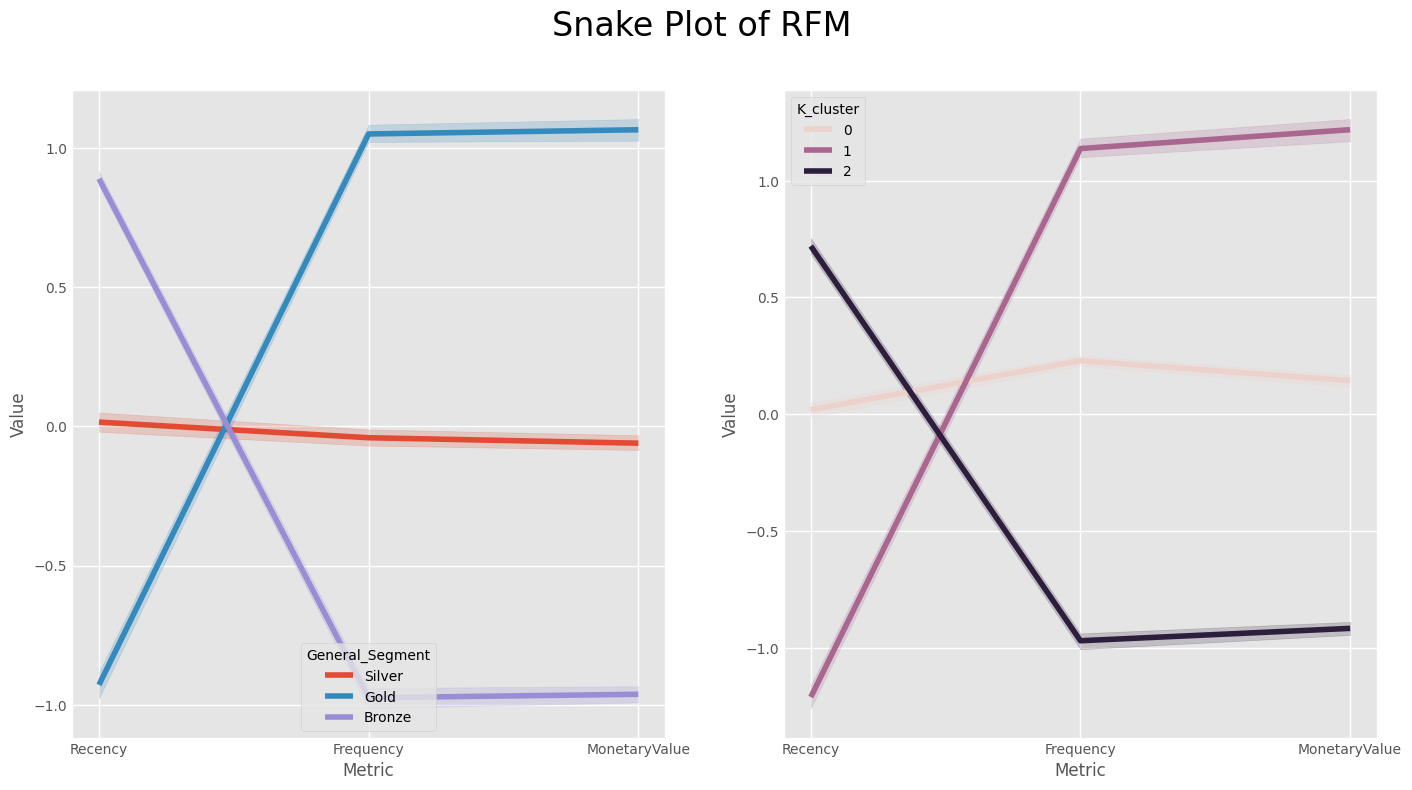

In [49]:
# ---- Step 6: Snake Plot ----
f, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 8))
sns.lineplot(x='Metric', y='Value', hue='General_Segment', data=rfm_melt, ax=ax1)
sns.lineplot(x='Metric', y='Value', hue='K_cluster', data=rfm_melt, ax=ax2)
plt.suptitle("Snake Plot of RFM", fontsize=24)
plt.show()

In [50]:
# ---- Step 7: Relative Importance ----
cluster_avg = df_rfm_k3.groupby('K_Cluster').mean()
population_avg = df_rfm.mean()
relative_imp = (cluster_avg / population_avg - 1).round(2)

total_avg = rfm[['Recency', 'Frequency', 'MonetaryValue']].mean()
cluster_avg2 = rfm.groupby('General_Segment')[['Recency', 'Frequency', 'MonetaryValue']].mean()
prop_rfm = (cluster_avg2 / total_avg - 1)

In [51]:
prop_rfm.round(2)

,Recency,Frequency,MonetaryValue
General_Segment,,,
Bronze,1.08,-0.83,-0.87
Gold,-0.78,1.49,1.56
Silver,-0.22,-0.45,-0.48


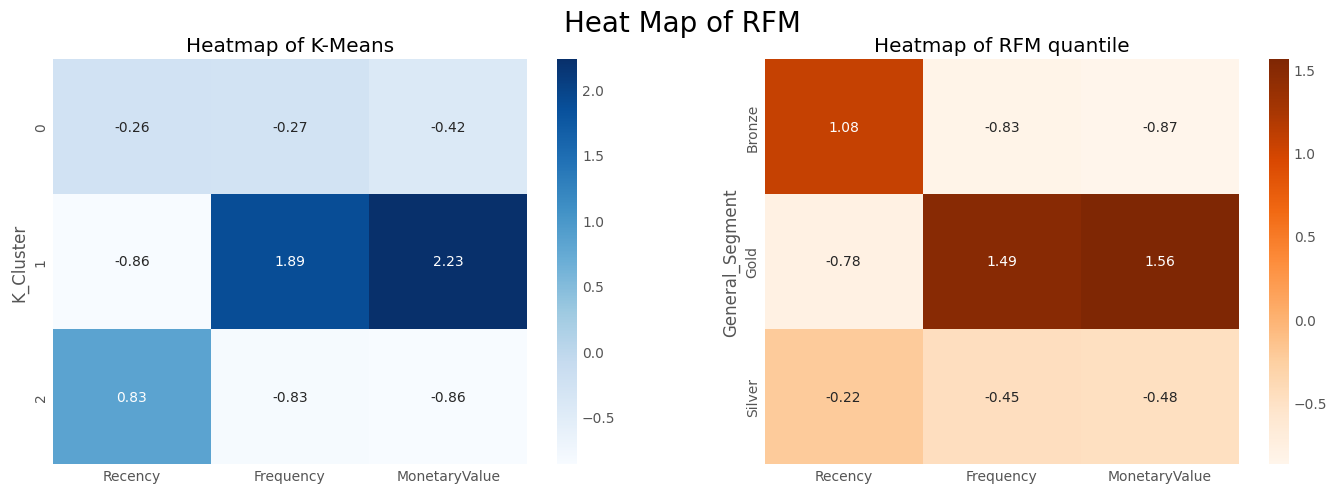

In [52]:
# ---- Step 8: Heatmaps ----
f, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
sns.heatmap(data=relative_imp, annot=True, fmt='.2f', cmap='Blues', ax=ax1)
ax1.set(title="Heatmap of K-Means")

sns.heatmap(prop_rfm, cmap='Oranges', fmt='.2f', annot=True, ax=ax2)
ax2.set(title="Heatmap of RFM quantile")

plt.suptitle("Heat Map of RFM", fontsize=20)
plt.show()

##  TENURE ANS CONCLUDING ACCORDING TO THE NEED OF THE COMPANY

In [53]:
# Calculate Tenure (days since first purchase)

tenure = data.groupby('CustomerID')['InvoiceDate'].min().apply(
    lambda x: (snapshot_date - x).days
)

# Add Tenure to the RFM dataset
rfm['Tenure'] = tenure

# Display updated RFM dataset
rfm.head()

,Recency,Frequency,MonetaryValue,R,F,M,RFM_Segment,RFM_Score,General_Segment,Tenure
CustomerID,,,,,,,,,,
12346.0,326,1,77183.60,1,1,4,1.01.04.0,6,Silver,326
12347.0,2,182,4310.00,4,4,4,4.04.04.0,12,Gold,367
12348.0,75,31,1797.24,2,2,4,2.02.04.0,8,Silver,358
12349.0,19,73,1757.55,3,3,4,3.03.04.0,10,Gold,19
12350.0,310,17,334.40,1,1,2,1.01.02.0,4,Bronze,310
